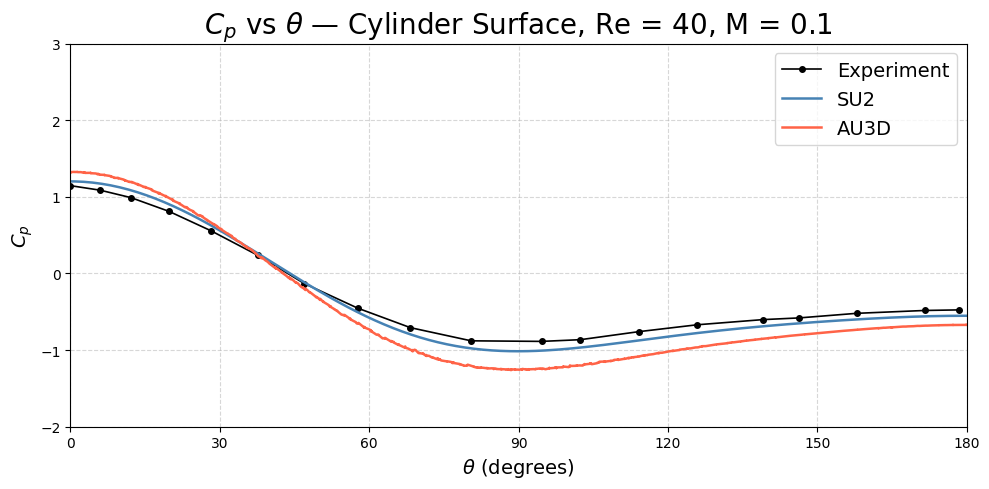

In [4]:
# cp vs theta plot

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ── Try to import AU3D utilities (optional) ───────────────────────────
try:
    from pyau3d.utils import PltFileUtils, UnkFileUtils
    HAS_AU3D = True
except ImportError:
    HAS_AU3D = False
    print("pyau3d not found — skipping AU3D data.")

# ── Parameters ────────────────────────────────────────────────────────
RE           = 40
gamma        = 1.4
farfield_p   = 1.73969        # Pa
farfield_u   = 34.0297        # m/s
farfield_rho = 2.10322e-5     # kg/m3

# ── SU2: Load surface CSV ─────────────────────────────────────────────
data_dir = "/home/ahf25/git/global_stability/data/Re40"
df = pd.read_csv(f"{data_dir}/su2_surface_flow_Re40.csv")

rho   = df['Density'].values
rho_u = df['Momentum_x'].values
rho_v = df['Momentum_y'].values
rho_E = df['Energy'].values
x     = df['x'].values
y     = df['y'].values

u = rho_u / rho
v = rho_v / rho
su2_surface_p = (gamma - 1.0) * (rho_E - 0.5 * rho * (u**2 + v**2))
su2_cp        = (su2_surface_p - farfield_p) / (0.5 * farfield_rho * farfield_u**2)

# theta: shift x to cylinder centre, upper surface only (0–180°)
x_centered = x - 0.5
val        = np.clip(-x_centered / 0.5, -1.0, 1.0)
theta_su2  = np.arccos(val) * 180.0 / np.pi
theta_full = np.where(y >= 0, theta_su2, 360.0 - theta_su2)

mask             = (theta_full >= 0) & (theta_full <= 180)
theta_su2_upper  = theta_full[mask]
cp_su2_upper     = su2_cp[mask]
idx              = np.argsort(theta_su2_upper)
theta_su2_sorted = theta_su2_upper[idx]
cp_su2_sorted    = cp_su2_upper[idx]

# ── AU3D: Load .plt / .rst files ──────────────────────────────────────
if HAS_AU3D:
    cfd_dir  = f"/home/ahf25/CFD_2d_cylinder_all/Steady/2d_cylinder_21228_Re{RE}"
    pltfile  = PltFileUtils(cfd_dir + "/cylinder.plt")
    rstfile  = UnkFileUtils(cfd_dir + "/cylinder.rst", extend=False)

    side_coords, side_nodes, side_nodemap = pltfile.extract_surface(flag=7)
    rstfile._primitive()

    surface_p  = rstfile.p[surface_nodes]
    surface_x  = surface_coords[:, 0]

    theta_au3d = np.arccos(-surface_x / 0.5) * 180.0 / np.pi
    au3d_cp    = (surface_p - farfield_p) / (0.5 * farfield_rho * farfield_u**2)

    idx_au3d       = np.argsort(theta_au3d)
    theta_au3d_sorted = np.array(theta_au3d)[idx_au3d]
    cp_au3d_sorted    = np.array(au3d_cp)[idx_au3d]

# ── Experimental data ─────────────────────────────────────────────────
data_dir = "/home/ahf25/git/global_stability/data/Re40"
cp_exp = pd.read_csv(f"{data_dir}/CpVsTheta_Re40.csv")
# ── Plot ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(cp_exp["x"], cp_exp[" y"],
        color='black', marker='o', markersize=4, linewidth=1.2,
        label='Experiment')

ax.plot(theta_su2_sorted, cp_su2_sorted,
        color='steelblue', linewidth=1.8,
        label='SU2')

if HAS_AU3D:
    ax.plot(theta_au3d_sorted, cp_au3d_sorted,
            color='tomato', linewidth=1.8,
            label='AU3D')

ax.invert_yaxis()
ax.set_xlabel(r'$\theta$ (degrees)', fontsize=14)
ax.set_ylabel(r'$C_p$', fontsize=14)
ax.set_title(rf'$C_p$ vs $\theta$ — Cylinder Surface, Re = {RE}, M = 0.1', fontsize=20)
ax.legend(fontsize=14)
ax.grid(True, linestyle='--', alpha=0.5)
ax.set_xlim([0, 180])
ax.set_xticks(range(0, 181, 30))
ax.set_ylim(-2, 3)
plt.tight_layout()
plt.savefig("cp_vs_theta_combined.png", dpi=150)
plt.show()